In [18]:
import sys
sys.path.insert(1, '..')

from physics.simulation import msq, sample as s
from physics.hzz import zpair, zz4l
from physics.hstar import c6

import hist
import matplotlib.pyplot as plt

In [3]:
SAMPLE_DIR = '../..'
COMPONENT = msq.Component.SBI

In [4]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

component_names = {
    msq.Component.SBI : 'SBI',
    msq.Component.SIG : 'SIG',
    msq.Component.INT : 'INT',
    msq.Component.BKG : 'BKG'
}

In [12]:
sample = s.from_csv(cross_section=xs[COMPONENT], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT]), n_rows=100000)
        
z_cand = zpair.ZPairCandidate(algorithm='truth')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
mandelstam = zz4l.MandelstamVariables()

sample = sample.calculate(z_cand).filter(z_masses).calculate(mandelstam)

X = sample.kinematics[['mandelstam_s', 'mandelstam_t', 'mandelstam_u']].to_numpy()

0.5379746106337265


In [19]:
c6_mod = c6.Modifier(baseline=COMPONENT, sample=sample, c6_values=[-5,-1,0,1,5])
c6wt, c6prob = c6_mod.modify([-10,0,10])

/tmp/ipykernel_17344/864902261.py:30: RuntimeWarning: invalid value encountered in divide
  ax2.step(h_s_sm.to_numpy()[1][:-1], h_s_sm.to_numpy()[0]/h_s_sm.to_numpy()[0], color='k', linestyle='--', label='SM')
/tmp/ipykernel_17344/864902261.py:31: RuntimeWarning: invalid value encountered in divide
  ax2.step(h_s_c6_1.to_numpy()[1][:-1], h_s_c6_1.to_numpy()[0]/h_s_sm.to_numpy()[0], color='r', label='c6=-10')
/tmp/ipykernel_17344/864902261.py:32: RuntimeWarning: invalid value encountered in divide
  ax2.step(h_s_c6_2.to_numpy()[1][:-1], h_s_c6_2.to_numpy()[0]/h_s_sm.to_numpy()[0], color='b', label='c6=10')


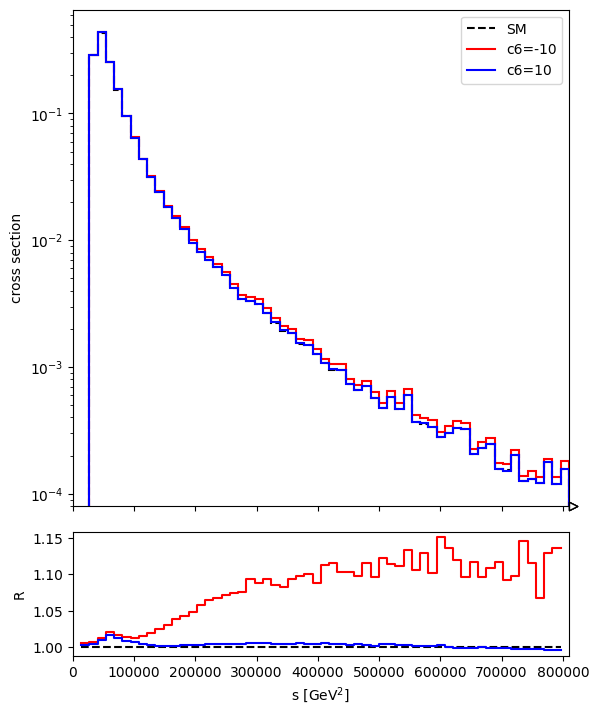

In [62]:
BINS = 60
bounds = [0,900**2]

h_s_sm = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_s_sm.fill(X[:,0], weight=c6wt[:,1])

h_s_c6_1 = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_s_c6_1.fill(X[:,0], weight=c6wt[:,0])

h_s_c6_2 = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_s_c6_2.fill(X[:,0], weight=c6wt[:,2])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

h_s_sm.plot(ax=ax1, color='k', linestyle='--', label='SM')
h_s_c6_1.plot(ax=ax1, color='r', label='c6=-10')
h_s_c6_2.plot(ax=ax1, color='b', label='c6=10')

ax1.set_yscale('log')
ax1.set_ylabel('cross section')
ax1.set_xlabel('')
ax1.set_xlim(*bounds)

ax1.legend()

plt.tight_layout()

ax2.step(h_s_sm.to_numpy()[1][:-1], h_s_sm.to_numpy()[0]/h_s_sm.to_numpy()[0], color='k', linestyle='--', label='SM')
ax2.step(h_s_c6_1.to_numpy()[1][:-1], h_s_c6_1.to_numpy()[0]/h_s_sm.to_numpy()[0], color='r', label='c6=-10')
ax2.step(h_s_c6_2.to_numpy()[1][:-1], h_s_c6_2.to_numpy()[0]/h_s_sm.to_numpy()[0], color='b', label='c6=10')

ax2.set_ylabel('R')
ax2.set_xlabel('s [GeV$^2$]')
ax2.set_xlim(*bounds)

plt.show()

/tmp/ipykernel_17344/3401335944.py:30: RuntimeWarning: invalid value encountered in divide
  ax2.step(h_t_sm.to_numpy()[1][:-1], h_t_sm.to_numpy()[0]/h_t_sm.to_numpy()[0], color='k', linestyle='--', label='SM')
/tmp/ipykernel_17344/3401335944.py:31: RuntimeWarning: invalid value encountered in divide
  ax2.step(h_t_c6_1.to_numpy()[1][:-1], h_t_c6_1.to_numpy()[0]/h_t_sm.to_numpy()[0], color='r', label='c6=-10')
/tmp/ipykernel_17344/3401335944.py:32: RuntimeWarning: invalid value encountered in divide
  ax2.step(h_t_c6_2.to_numpy()[1][:-1], h_t_c6_2.to_numpy()[0]/h_t_sm.to_numpy()[0], color='b', label='c6=10')


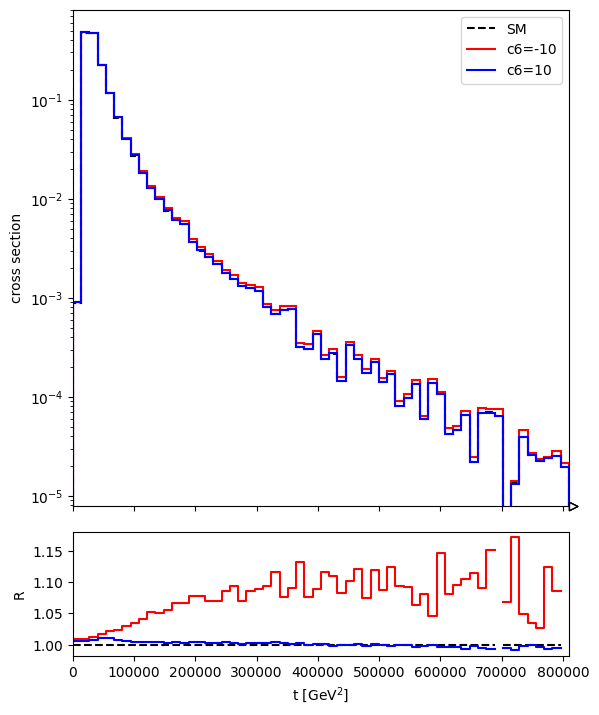

In [60]:
BINS = 60
bounds = [0,900**2]

h_t_sm = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_t_sm.fill(X[:,1], weight=c6wt[:,1])

h_t_c6_1 = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_t_c6_1.fill(X[:,1], weight=c6wt[:,0])

h_t_c6_2 = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_t_c6_2.fill(X[:,1], weight=c6wt[:,2])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

h_t_sm.plot(ax=ax1, color='k', linestyle='--', label='SM')
h_t_c6_1.plot(ax=ax1, color='r', label='c6=-10')
h_t_c6_2.plot(ax=ax1, color='b', label='c6=10')

ax1.set_yscale('log')
ax1.set_ylabel('cross section')
ax1.set_xlabel('')
ax1.set_xlim(*bounds)

ax1.legend()

plt.tight_layout()

ax2.step(h_t_sm.to_numpy()[1][:-1], h_t_sm.to_numpy()[0]/h_t_sm.to_numpy()[0], color='k', linestyle='--', label='SM')
ax2.step(h_t_c6_1.to_numpy()[1][:-1], h_t_c6_1.to_numpy()[0]/h_t_sm.to_numpy()[0], color='r', label='c6=-10')
ax2.step(h_t_c6_2.to_numpy()[1][:-1], h_t_c6_2.to_numpy()[0]/h_t_sm.to_numpy()[0], color='b', label='c6=10')

ax2.set_ylabel('R')
ax2.set_xlabel('t [GeV$^2$]')
ax2.set_xlim(*bounds)

plt.show()

/tmp/ipykernel_17344/1336035898.py:30: RuntimeWarning: invalid value encountered in divide
  ax2.step(h_u_sm.to_numpy()[1][:-1], h_u_sm.to_numpy()[0]/h_u_sm.to_numpy()[0], color='k', linestyle='--', label='SM')
/tmp/ipykernel_17344/1336035898.py:31: RuntimeWarning: invalid value encountered in divide
  ax2.step(h_u_c6_1.to_numpy()[1][:-1], h_u_c6_1.to_numpy()[0]/h_u_sm.to_numpy()[0], color='r', label='c6=-10')
/tmp/ipykernel_17344/1336035898.py:32: RuntimeWarning: invalid value encountered in divide
  ax2.step(h_u_c6_2.to_numpy()[1][:-1], h_u_c6_2.to_numpy()[0]/h_u_sm.to_numpy()[0], color='b', label='c6=10')


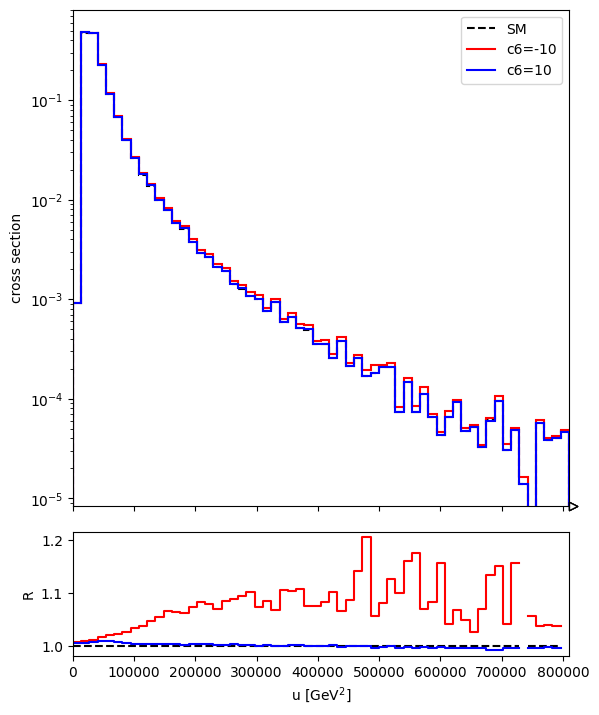

In [61]:
BINS = 60
bounds = [0,900**2]

h_u_sm = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_u_sm.fill(X[:,2], weight=c6wt[:,1])

h_u_c6_1 = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_u_c6_1.fill(X[:,2], weight=c6wt[:,0])

h_u_c6_2 = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_u_c6_2.fill(X[:,2], weight=c6wt[:,2])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

h_u_sm.plot(ax=ax1, color='k', linestyle='--', label='SM')
h_u_c6_1.plot(ax=ax1, color='r', label='c6=-10')
h_u_c6_2.plot(ax=ax1, color='b', label='c6=10')

ax1.set_yscale('log')
ax1.set_ylabel('cross section')
ax1.set_xlabel('')
ax1.set_xlim(*bounds)

ax1.legend()

plt.tight_layout()

ax2.step(h_u_sm.to_numpy()[1][:-1], h_u_sm.to_numpy()[0]/h_u_sm.to_numpy()[0], color='k', linestyle='--', label='SM')
ax2.step(h_u_c6_1.to_numpy()[1][:-1], h_u_c6_1.to_numpy()[0]/h_u_sm.to_numpy()[0], color='r', label='c6=-10')
ax2.step(h_u_c6_2.to_numpy()[1][:-1], h_u_c6_2.to_numpy()[0]/h_u_sm.to_numpy()[0], color='b', label='c6=10')

ax2.set_ylabel('R')
ax2.set_xlabel('u [GeV$^2$]')
ax2.set_xlim(*bounds)

plt.show()

/tmp/ipykernel_17344/1164678081.py:30: RuntimeWarning: invalid value encountered in divide
  ax2.step(h_s.to_numpy()[1][:-1], h_s.to_numpy()[0]/h_s.to_numpy()[0], color='k', linestyle='--', label='s')
/tmp/ipykernel_17344/1164678081.py:31: RuntimeWarning: divide by zero encountered in divide
  ax2.step(h_t.to_numpy()[1][:-1], h_t.to_numpy()[0]/h_s.to_numpy()[0], color='r', label='t')
/tmp/ipykernel_17344/1164678081.py:32: RuntimeWarning: divide by zero encountered in divide
  ax2.step(h_u.to_numpy()[1][:-1], h_u.to_numpy()[0]/h_s.to_numpy()[0], color='b', label='u')


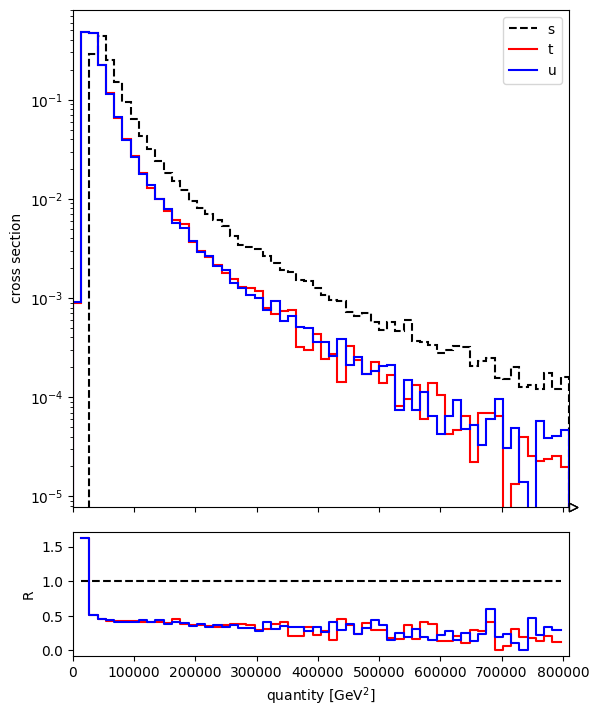

In [64]:
BINS = 60
bounds = [0,900**2]

h_s = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_s.fill(X[:,0], weight=c6wt[:,1])

h_t = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_t.fill(X[:,1], weight=c6wt[:,1])

h_u = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_u.fill(X[:,2], weight=c6wt[:,1])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

h_s.plot(ax=ax1, color='k', linestyle='--', label='s')
h_t.plot(ax=ax1, color='r', label='t')
h_u.plot(ax=ax1, color='b', label='u')

ax1.set_yscale('log')
ax1.set_ylabel('cross section')
ax1.set_xlabel('')
ax1.set_xlim(*bounds)

ax1.legend()

plt.tight_layout()

ax2.step(h_s.to_numpy()[1][:-1], h_s.to_numpy()[0]/h_s.to_numpy()[0], color='k', linestyle='--', label='s')
ax2.step(h_t.to_numpy()[1][:-1], h_t.to_numpy()[0]/h_s.to_numpy()[0], color='r', label='t')
ax2.step(h_u.to_numpy()[1][:-1], h_u.to_numpy()[0]/h_s.to_numpy()[0], color='b', label='u')

ax2.set_ylabel('R')
ax2.set_xlabel('quantity [GeV$^2$]')
ax2.set_xlim(*bounds)

plt.show()